Install Library

In [3]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn
%pip install missingno


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Load Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno  # For visualizing missing values
import warnings
warnings.filterwarnings("ignore")


In [3]:
df = pd.read_csv("Car_Features_and_MSRP.csv")  # Update file path if needed

Dataset Overview

In [3]:
df.head()  # View first 5 rows
df.tail()  # View last 5 rows
df.sample(5)  # Random samples
df.shape  # Check rows and columns
df.columns  # List all columns
df.dtypes  # Data types of each column

Make                  object
Model                 object
Year                   int64
Engine Fuel Type      object
Engine HP            float64
Engine Cylinders     float64
Transmission Type     object
Driven_Wheels         object
Number of Doors      float64
Market Category       object
Vehicle Size          object
Vehicle Style         object
highway MPG            int64
city mpg               int64
Popularity             int64
MSRP                   int64
dtype: object

Missing Values Analysis

In [4]:
df.isnull().sum()  # Count missing values
df.isnull().mean() * 100  # Percentage of missing values

Make                  0.000000
Model                 0.000000
Year                  0.000000
Engine Fuel Type      0.025180
Engine HP             0.579151
Engine Cylinders      0.251805
Transmission Type     0.000000
Driven_Wheels         0.000000
Number of Doors       0.050361
Market Category      31.408427
Vehicle Size          0.000000
Vehicle Style         0.000000
highway MPG           0.000000
city mpg              0.000000
Popularity            0.000000
MSRP                  0.000000
dtype: float64

Visualizing Missing Data

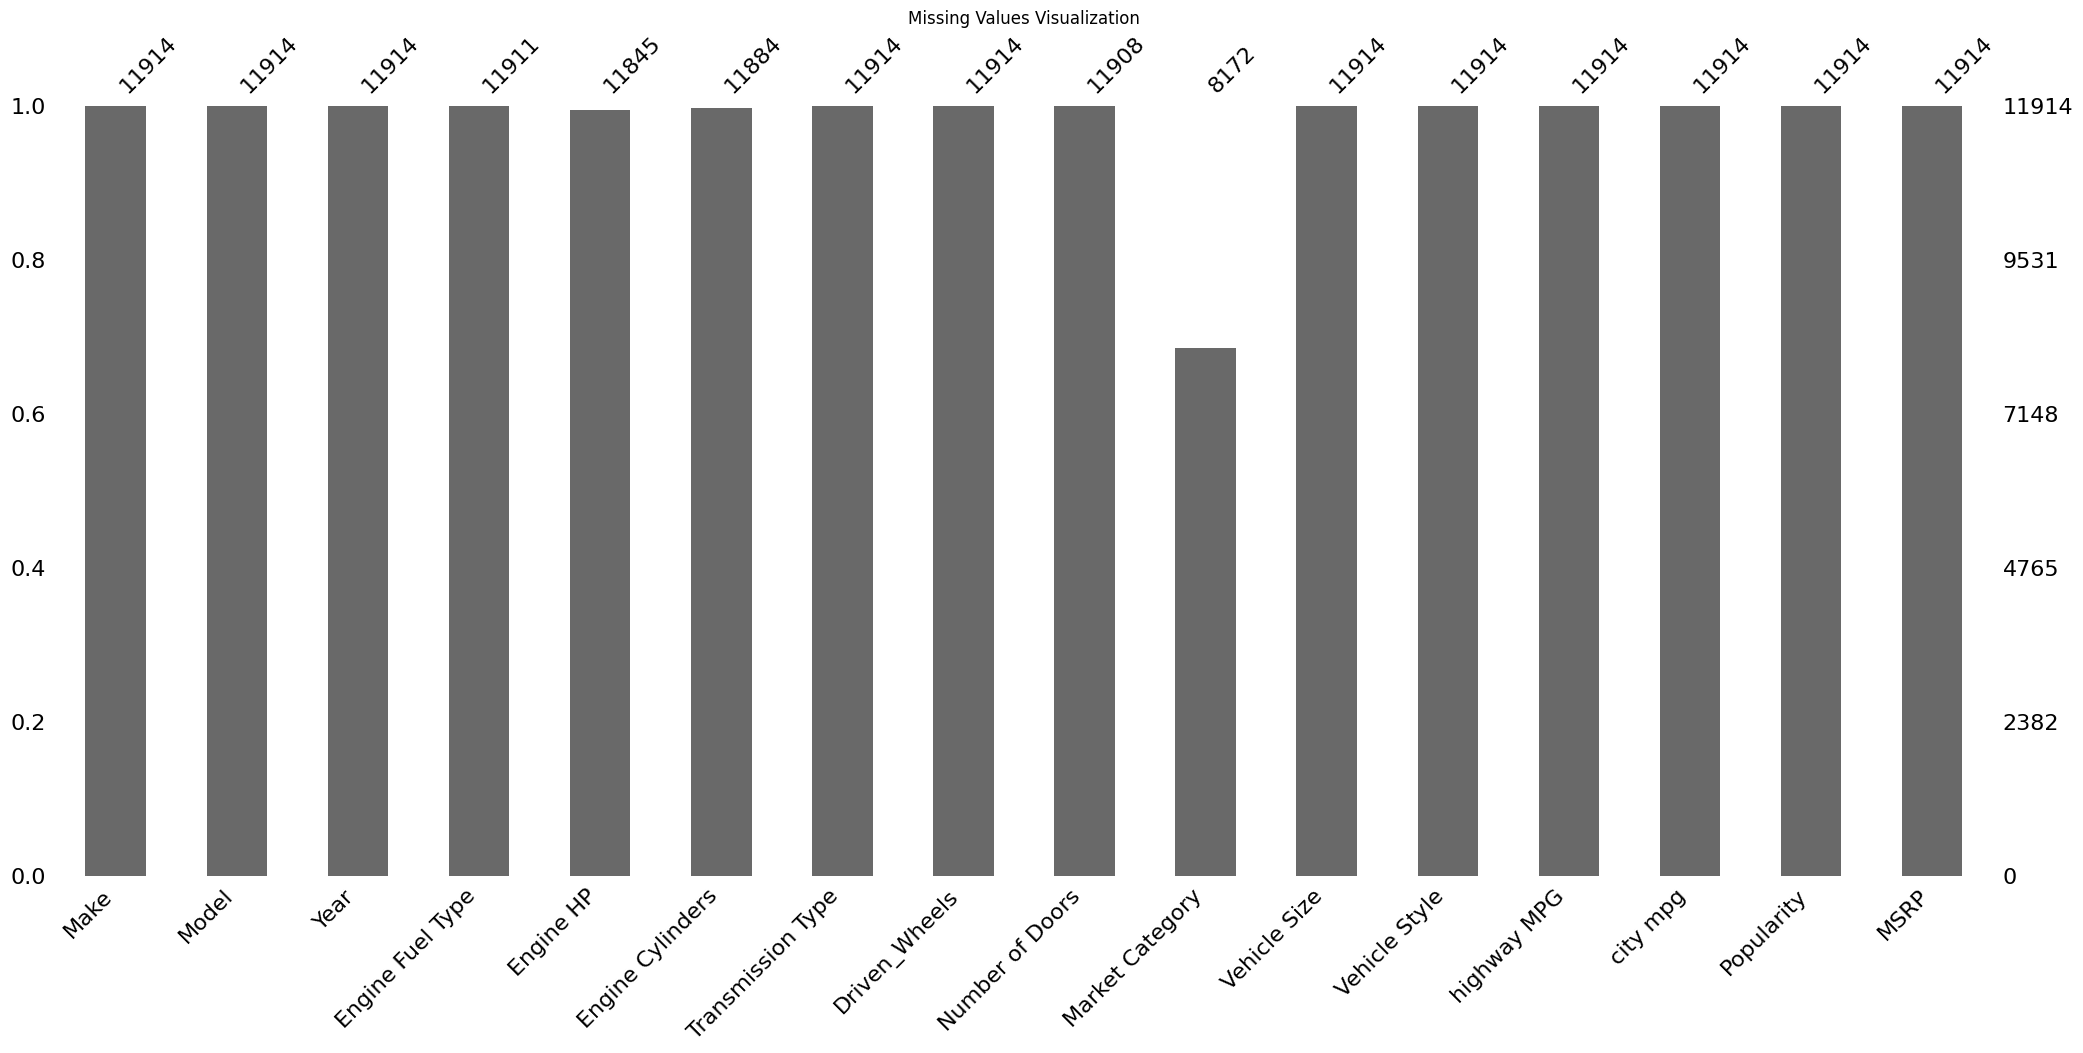

In [5]:
plt.figure(figsize=(12, 6))
msno.bar(df)
plt.title("Missing Values Visualization")
plt.show()

<Figure size 1200x600 with 0 Axes>

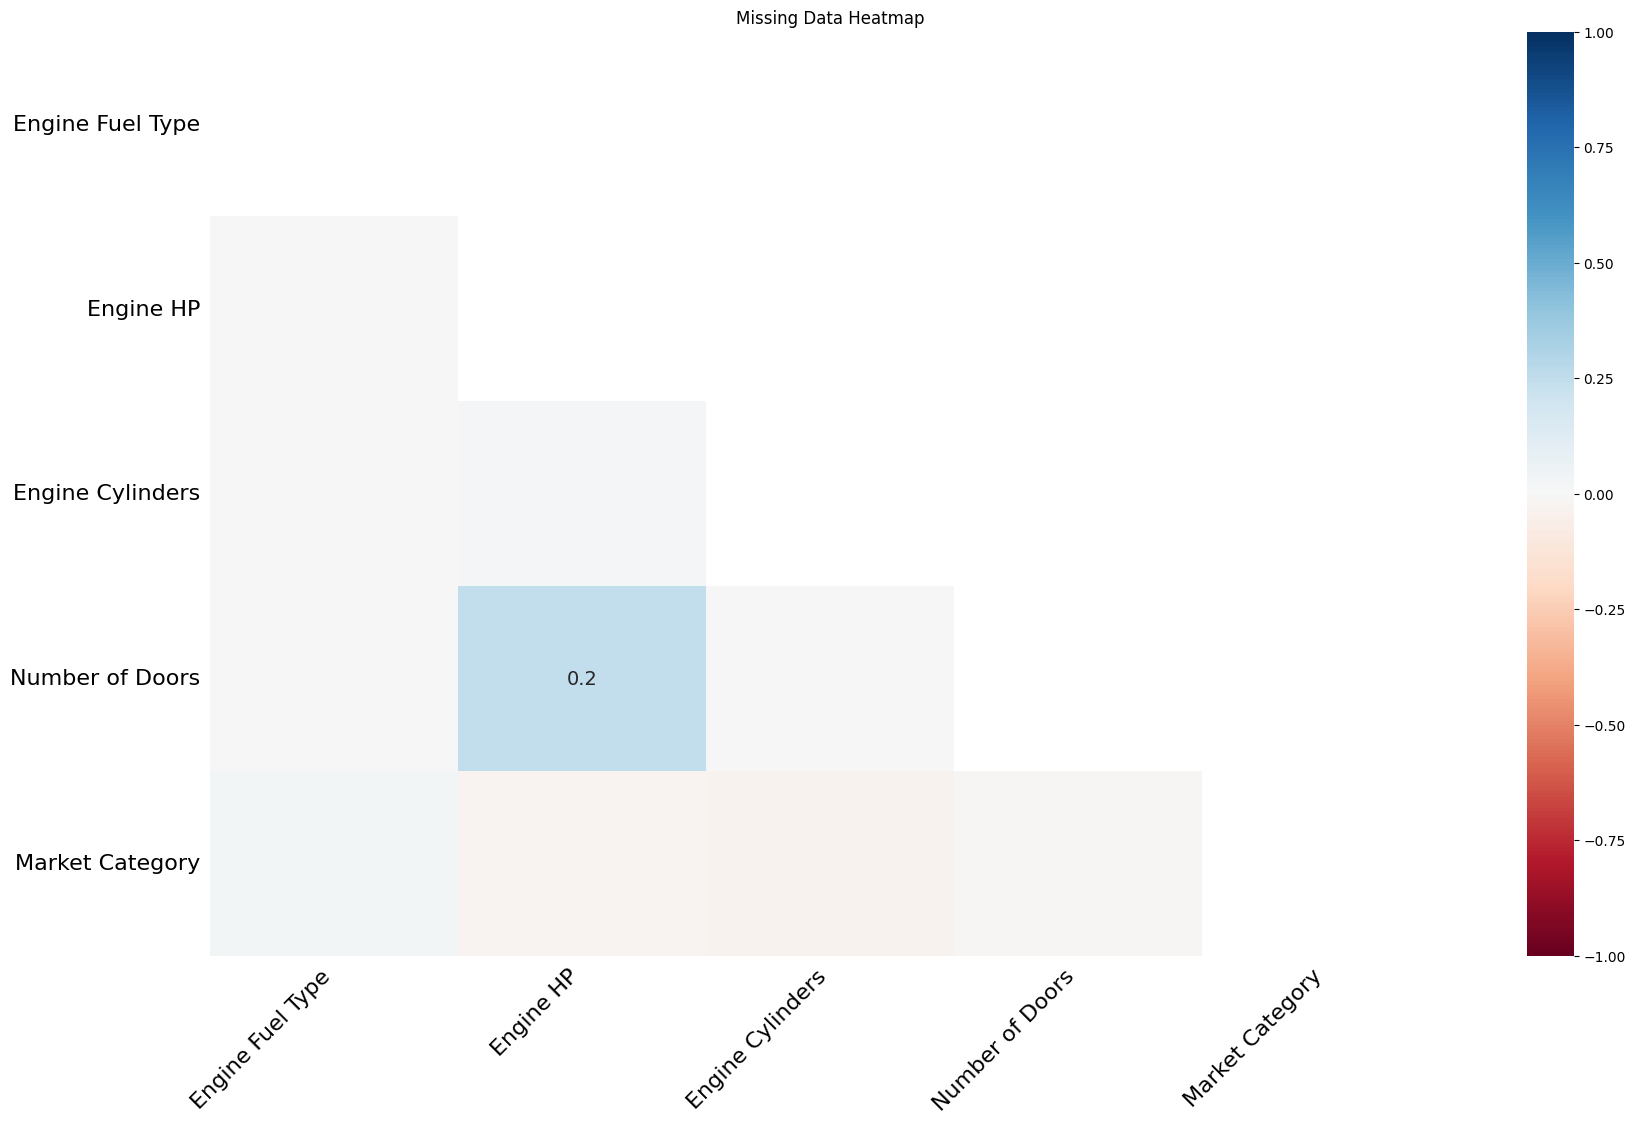

In [6]:
plt.figure(figsize=(12, 6))
msno.heatmap(df)
plt.title("Missing Data Heatmap")
plt.show()

Handling Missing values

In [7]:
df.dropna(subset=['MSRP'], inplace=True)  # Remove rows where MSRP is missing
df.fillna(df.median(numeric_only=True), inplace=True)  # Fill numerical NaNs
df.fillna(df.mode().iloc[0], inplace=True)  # Fill categorical NaNs

Data Summary

In [8]:
df.describe()  # Statistical summary of numerical features
df.describe(include='object')  # Summary of categorical features
df.nunique()  # Count of unique values in each column

Make                   48
Model                 915
Year                   28
Engine Fuel Type       10
Engine HP             356
Engine Cylinders        9
Transmission Type       5
Driven_Wheels           4
Number of Doors         3
Market Category        71
Vehicle Size            3
Vehicle Style          16
highway MPG            59
city mpg               69
Popularity             48
MSRP                 6049
dtype: int64

Outlier Detection

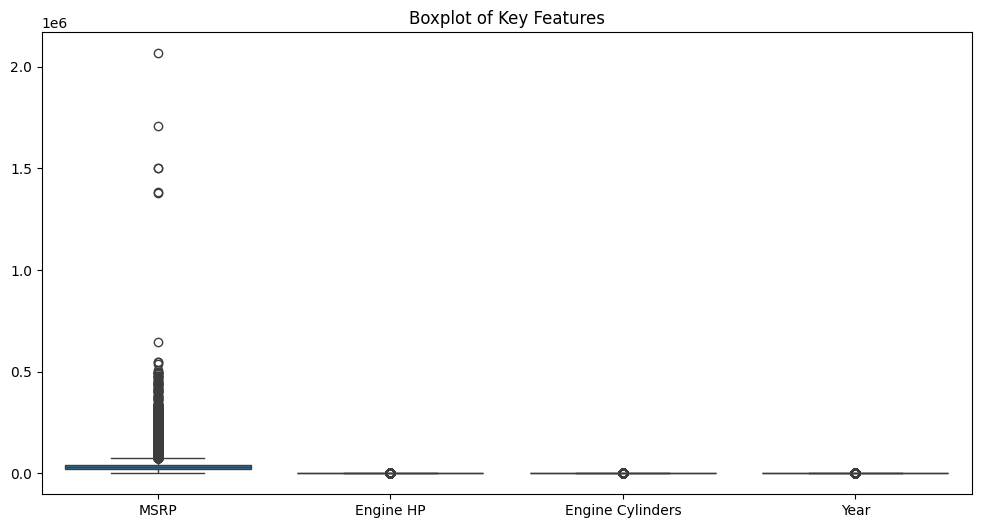

In [9]:
# Boxplots for Outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['MSRP', 'Engine HP', 'Engine Cylinders', 'Year']])
plt.title("Boxplot of Key Features")
plt.show()

Removing Outliers Using IQR

In [10]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

df = remove_outliers(df, 'MSRP')
df = remove_outliers(df, 'Engine HP')

Univariate Analysis

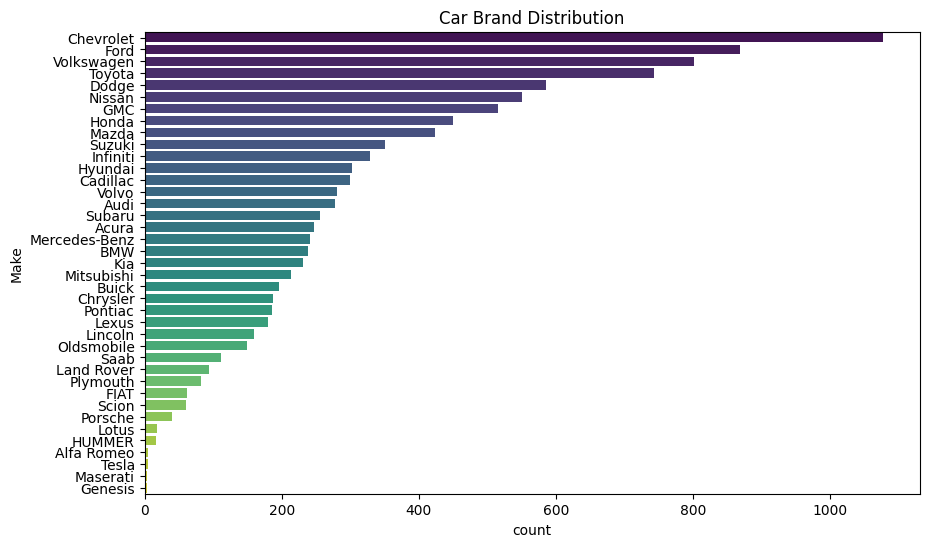

In [11]:
# Categorical Features
plt.figure(figsize=(10, 6))
sns.countplot(y=df['Make'], order=df['Make'].value_counts().index, palette="viridis")
plt.title("Car Brand Distribution")
plt.show()

Numerical Features

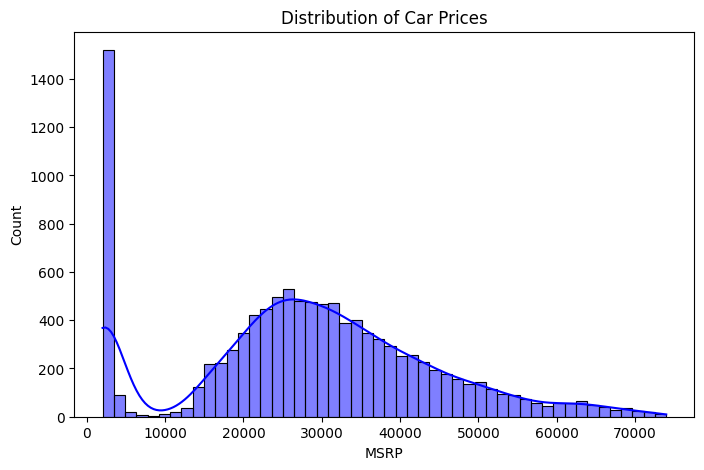

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df['MSRP'], bins=50, kde=True, color="blue")
plt.title("Distribution of Car Prices")
plt.show()

Bivariate Analysis

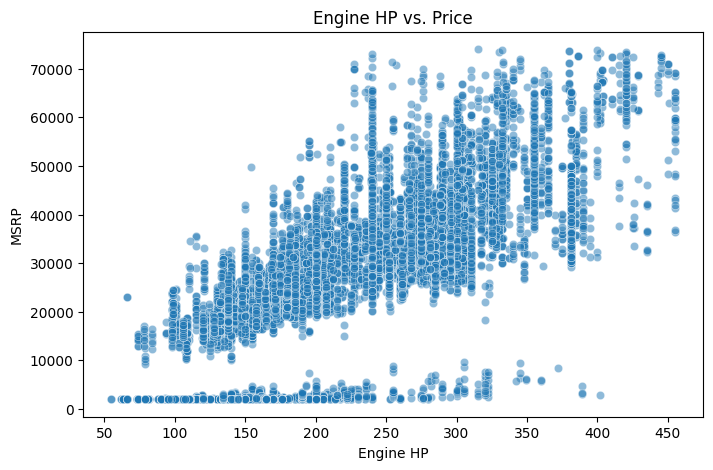

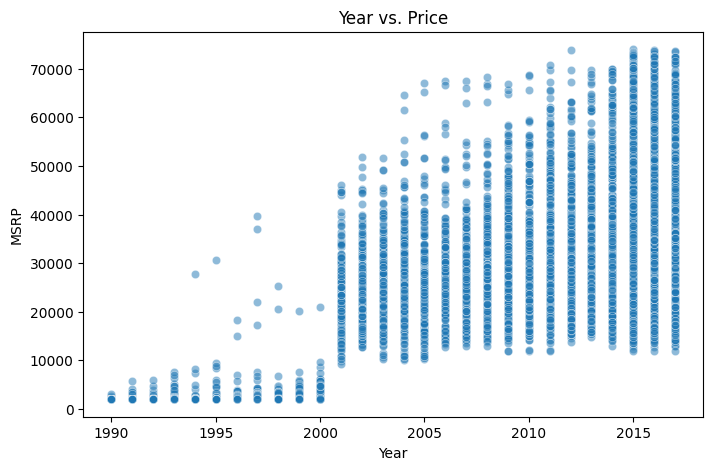

In [13]:
# Scatter Plots (Feature vs. MSRP)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['Engine HP'], y=df['MSRP'], alpha=0.5)
plt.title("Engine HP vs. Price")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['Year'], y=df['MSRP'], alpha=0.5)
plt.title("Year vs. Price")
plt.show()

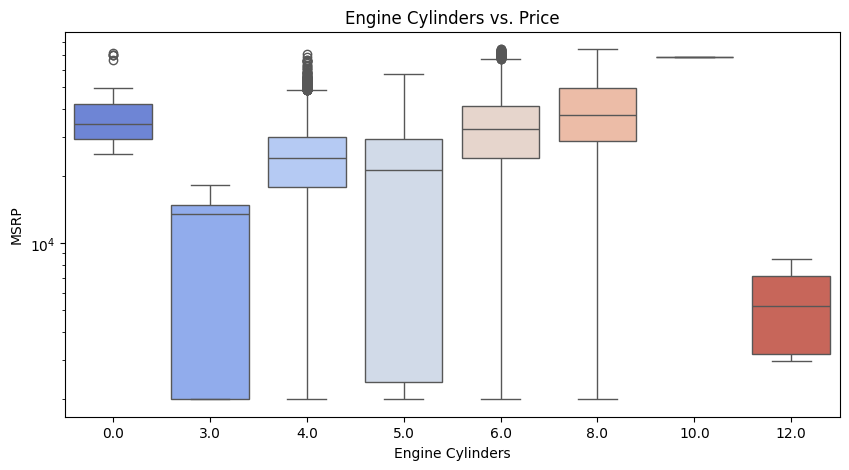

In [14]:
# Boxplots (Categorical vs. MSRP)
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Engine Cylinders'], y=df['MSRP'], palette="coolwarm")
plt.title("Engine Cylinders vs. Price")
plt.yscale("log")  # Log scale for better visibility
plt.show()

Correlation Analysis

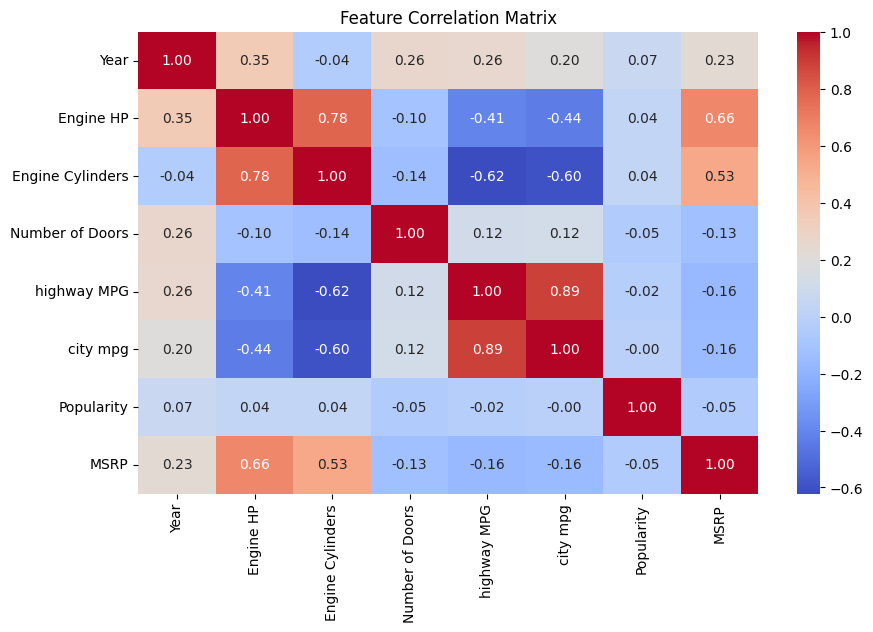

In [4]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

In [5]:
correlation = df.select_dtypes(include=['number']).corr()['MSRP'].sort_values(ascending=False)
print(correlation)

MSRP                1.000000
Engine HP           0.662008
Engine Cylinders    0.531312
Year                0.227590
Popularity         -0.048476
Number of Doors    -0.126635
city mpg           -0.157676
highway MPG        -0.160043
Name: MSRP, dtype: float64


Feature Engineering

In [17]:
# Encoding Categorical Variables
df = pd.get_dummies(df, columns=['Make', 'Model', 'Transmission', 'Fuel Type'], drop_first=True)

KeyError: "['Transmission', 'Fuel Type'] not in index"

Transforming Price Variable

In [18]:
df['log_MSRP'] = np.log(df['MSRP'])  # Normalize price

Insights & Summary

In [19]:
# Top 5 most expensive brands
df.groupby("Make")["MSRP"].mean().sort_values(ascending=False).head(5)

Make
Maserati      71000.000000
Tesla         69360.000000
Alfa Romeo    61600.000000
Lotus         60245.000000
Cadillac      47982.050167
Name: MSRP, dtype: float64

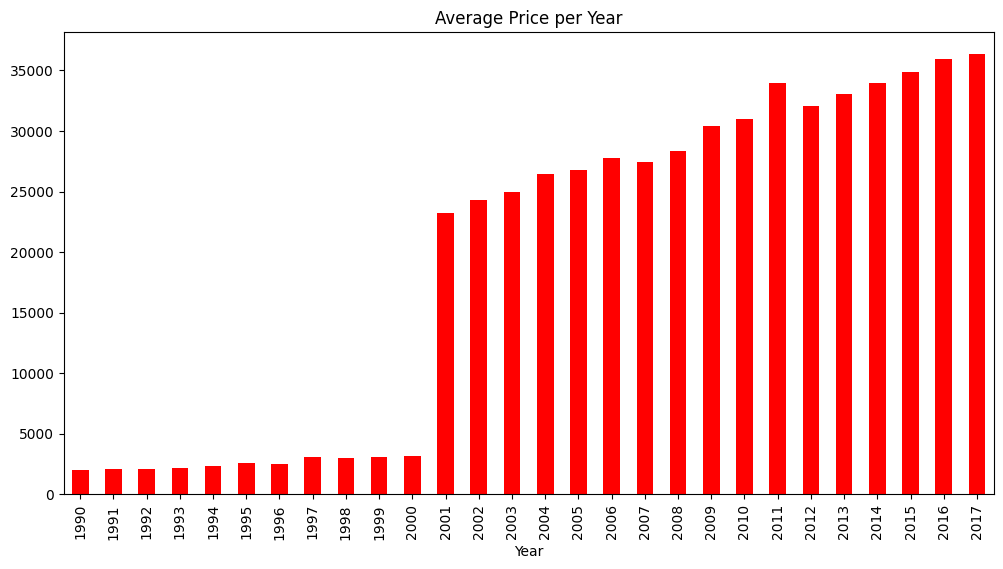

In [20]:
# Which year has the highest average car price?
df.groupby("Year")["MSRP"].mean().plot(kind="bar", figsize=(12, 6), color="red")
plt.title("Average Price per Year")
plt.show()

Enhancing the EDA for Price & Profitability Analysis

In [21]:
# Feature Importance on Price (MSRP)
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr()[['MSRP']].sort_values(by="MSRP", ascending=False), annot=True, cmap='coolwarm')
plt.title("Correlation of Features with Price (MSRP)")
plt.show()

ValueError: could not convert string to float: 'BMW'

<Figure size 1000x600 with 0 Axes>

In [14]:
# Estimate Cost Price as 70% of MSRP
df["Estimated Cost Price"] = df["MSRP"] * 0.7  

# Profitability Estimation
df['Profit'] = df['MSRP'] - df['Estimated Cost Price']
df['Profit Margin (%)'] = (df['Profit'] / df['MSRP']) * 100

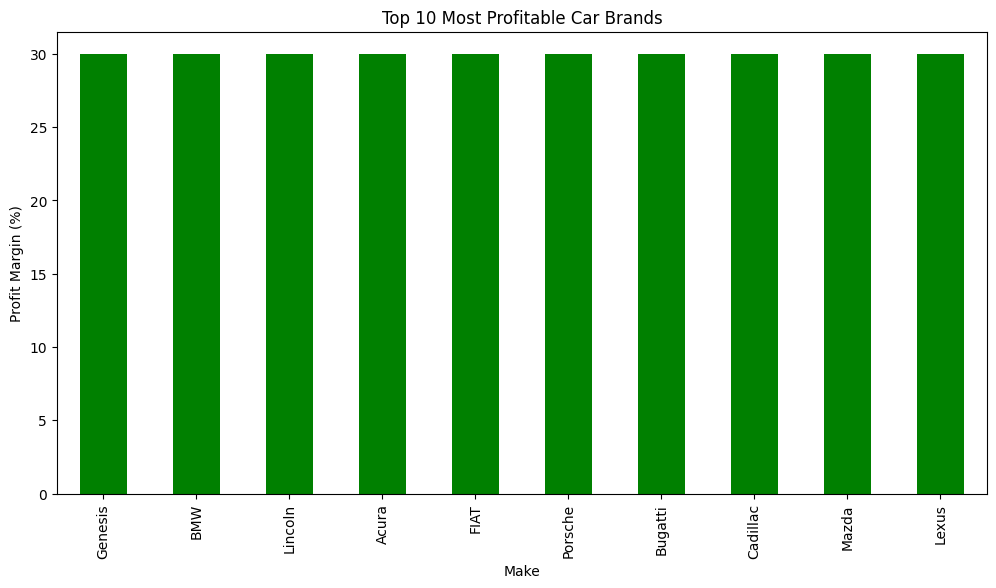

In [17]:
# Profitability by Car Brand
brand_profit = df.groupby("Make")["Profit Margin (%)"].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
brand_profit.head(10).plot(kind='bar', color='green')
plt.title("Top 10 Most Profitable Car Brands")
plt.ylabel("Profit Margin (%)")
plt.show()

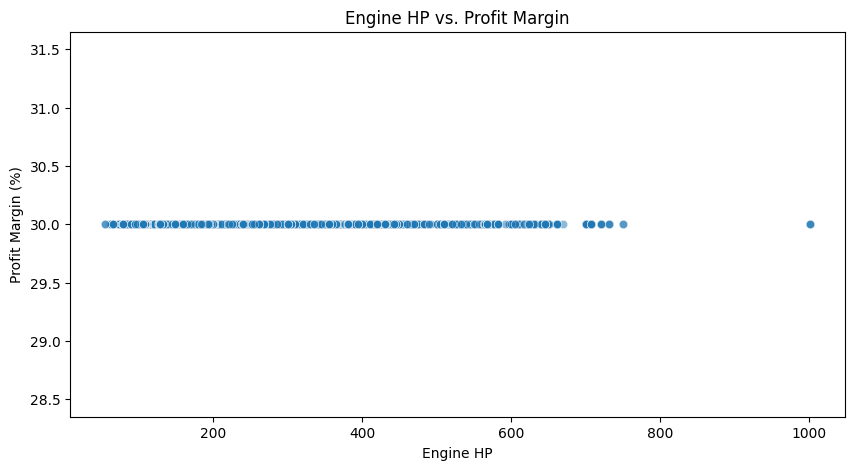

In [18]:
# Feature Impact on Profitability
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df["Engine HP"], y=df["Profit Margin (%)"], alpha=0.5)
plt.title("Engine HP vs. Profit Margin")
plt.show()

In [19]:
# Impact of Fuel Type on Profitability
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Fuel Type"], y=df["Profit Margin (%)"], palette="coolwarm")
plt.title("Profitability Across Fuel Types")
plt.show()

KeyError: 'Fuel Type'

<Figure size 800x500 with 0 Axes>

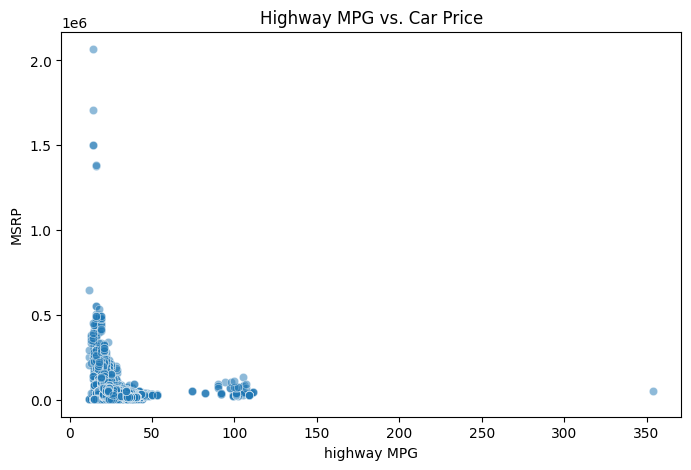

In [21]:
# Price Elasticity Analysis
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["highway MPG"], y=df["MSRP"], alpha=0.5)
plt.title("Highway MPG vs. Car Price")
plt.show()

In [6]:
# Estimate Cost Price as 70% of MSRP
df["Estimated Cost Price"] = df["MSRP"] * 0.7  

# Calculate Profit Margin %
df["Profit Margin (%)"] = ((df["MSRP"] - df["Estimated Cost Price"]) / df["MSRP"]) * 100  

# Drop the assumed cost price column (optional)
df.drop(columns=["Estimated Cost Price"], inplace=True)

# Verify the new column
print(df[["MSRP", "Profit Margin (%)"]].head())

    MSRP  Profit Margin (%)
0  46135               30.0
1  40650               30.0
2  36350               30.0
3  29450               30.0
4  34500               30.0


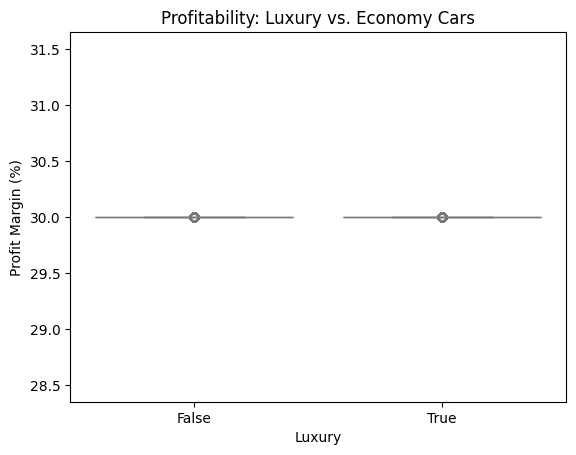

In [9]:
# High-Profit Segments
df['Luxury'] = df['MSRP'] > df['MSRP'].median()  # Define luxury cars as above median price
sns.boxplot(x=df["Luxury"], y=df["Profit Margin (%)"], palette="coolwarm")
plt.title("Profitability: Luxury vs. Economy Cars")
plt.show()

In [11]:
# Predicting Price Based on Features
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

df_cleaned = df.dropna(subset=['Engine HP', 'Engine Cylinders', 'Year', 'highway MPG', 'MSRP'])

# Redefine X and y with cleaned data
X = df_cleaned[['Engine HP', 'Engine Cylinders', 'Year', 'highway MPG']]
y = df_cleaned['MSRP']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"R² Score: {r2_score(y_test, y_pred):.2f}")

R² Score: 0.45
